In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv('apple_5yr_one.csv')

# Show first 5 rows
print(df.head())

         Date              Close               High                Low  \
0         NaN               AAPL               AAPL               AAPL   
1  2020-06-04  78.32931518554688   79.1312690763083  77.95506657558614   
2  2020-06-05  80.56021881103516  80.62097312386399  78.55046881252456   
3  2020-06-08  81.03653717041016  81.07056314819836  79.54441498185327   
4  2020-06-09  83.59550476074219  83.98919153470604  80.68416273702039   

                Open     Volume  
0               AAPL       AAPL  
1  78.83236263047952   87560400  
2  78.57962969607472  137250400  
3  80.25645380649277   95654400  
4  80.71575616737768  147712400  


In [6]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1255 non-null   object
 1   Close   1256 non-null   object
 2   High    1256 non-null   object
 3   Low     1256 non-null   object
 4   Open    1256 non-null   object
 5   Volume  1256 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB
None


In [8]:
# Remove the bad first row
df = df.drop(0)

# Convert Date column into datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert numeric columns
df['Close'] = pd.to_numeric(df['Close'])
df['High'] = pd.to_numeric(df['High'])
df['Low'] = pd.to_numeric(df['Low'])
df['Open'] = pd.to_numeric(df['Open'])
df['Volume'] = pd.to_numeric(df['Volume'])

# Check data types again
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 1 to 1255
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   float64       
 2   High    1255 non-null   float64       
 3   Low     1255 non-null   float64       
 4   Open    1255 non-null   float64       
 5   Volume  1255 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.0 KB
None


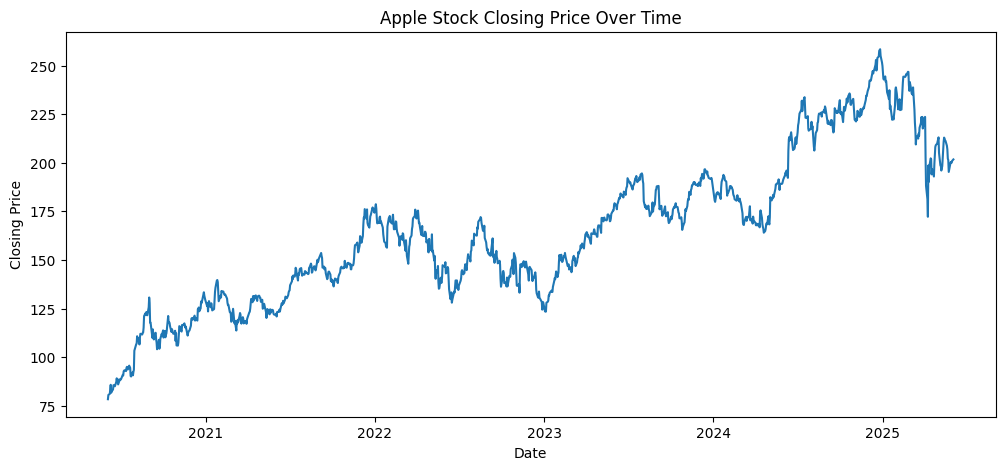

In [9]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(12,5))

# Plot closing price over time
plt.plot(df['Date'], df['Close'])

# Titles and labels
plt.title('Apple Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

# Show chart
plt.show()

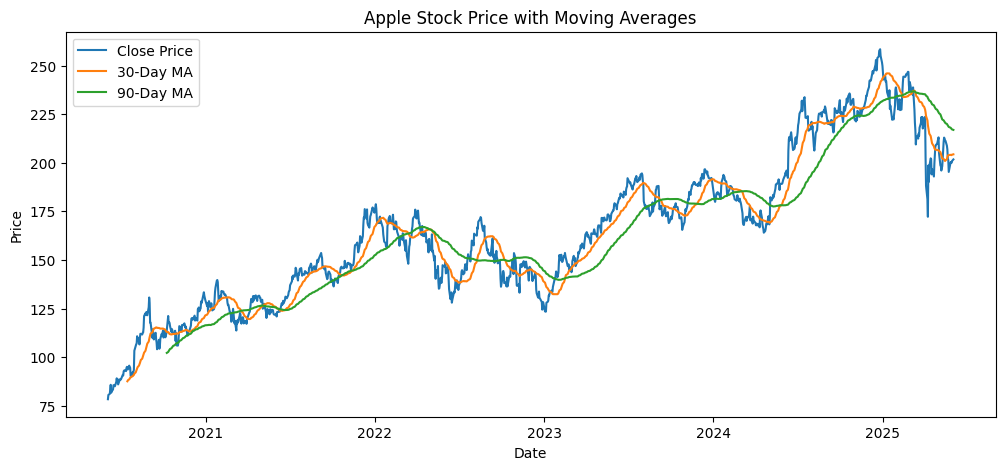

In [10]:
# Create moving averages
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_90'] = df['Close'].rolling(window=90).mean()

# Plot chart
plt.figure(figsize=(12,5))

# Original closing price
plt.plot(df['Date'], df['Close'], label='Close Price')

# Moving averages
plt.plot(df['Date'], df['MA_30'], label='30-Day MA')
plt.plot(df['Date'], df['MA_90'], label='90-Day MA')

# Labels and title
plt.title('Apple Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

# Show legend
plt.legend()

# Show chart
plt.show()

/tmp/ipykernel_3059/615822325.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_volume = df['Volume'].resample('M').sum()


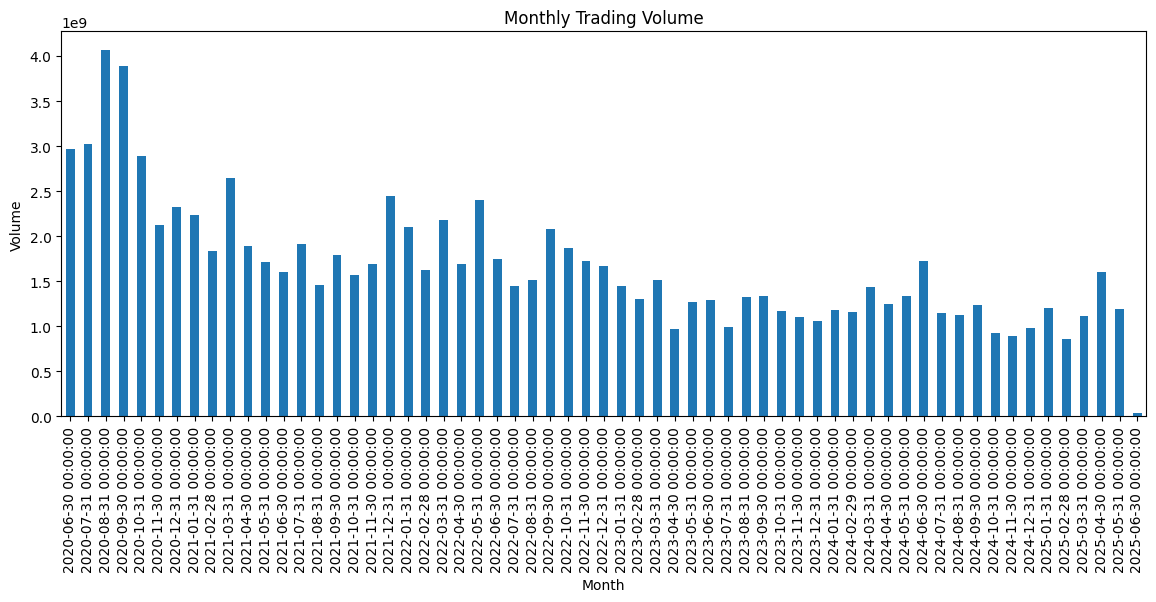

In [11]:
# Set Date as index
df.set_index('Date', inplace=True)

# Monthly trading volume
monthly_volume = df['Volume'].resample('M').sum()

# Plot bar chart
plt.figure(figsize=(14,5))

monthly_volume.plot(kind='bar')

# Titles and labels
plt.title('Monthly Trading Volume')
plt.xlabel('Month')
plt.ylabel('Volume')

# Show chart
plt.show()

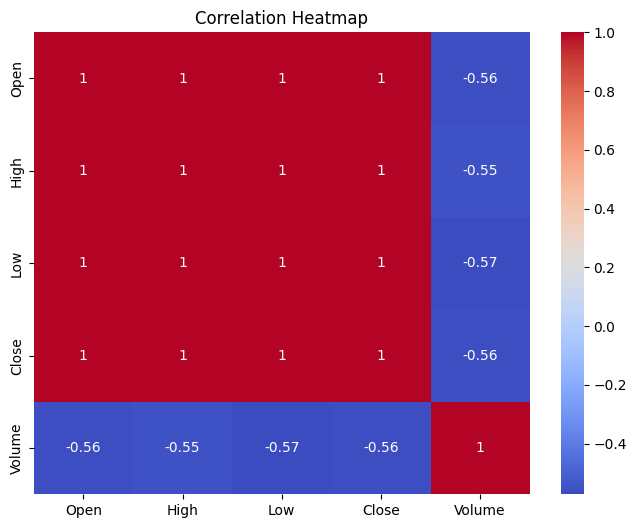

In [12]:
import seaborn as sns

# Correlation matrix
correlation = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

# Create heatmap
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

# Title
plt.title('Correlation Heatmap')

# Show chart
plt.show()

In [13]:
!pip install statsmodels

In [14]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Use closing prices
close_prices = df['Close']

# Build ARIMA model
model = ARIMA(close_prices, order=(5,1,0))

# Train model
model_fit = model.fit()

# Forecast next 30 days
forecast = model_fit.forecast(steps=30)

# Print forecasted values
print(forecast)

1255    201.675550
1256    201.662404
1257    201.596533
1258    201.554953
1259    201.541558
1260    201.544490
1261    201.548669
1262    201.551825
1263    201.552886
1264    201.552870
1265    201.552555
1266    201.552330
1267    201.552238
1268    201.552232
1269    201.552252
1270    201.552268
1271    201.552276
1272    201.552277
1273    201.552276
1274    201.552274
1275    201.552274
1276    201.552274
1277    201.552274
1278    201.552274
1279    201.552274
1280    201.552274
1281    201.552274
1282    201.552274
1283    201.552274
1284    201.552274
Name: predicted_mean, dtype: float64


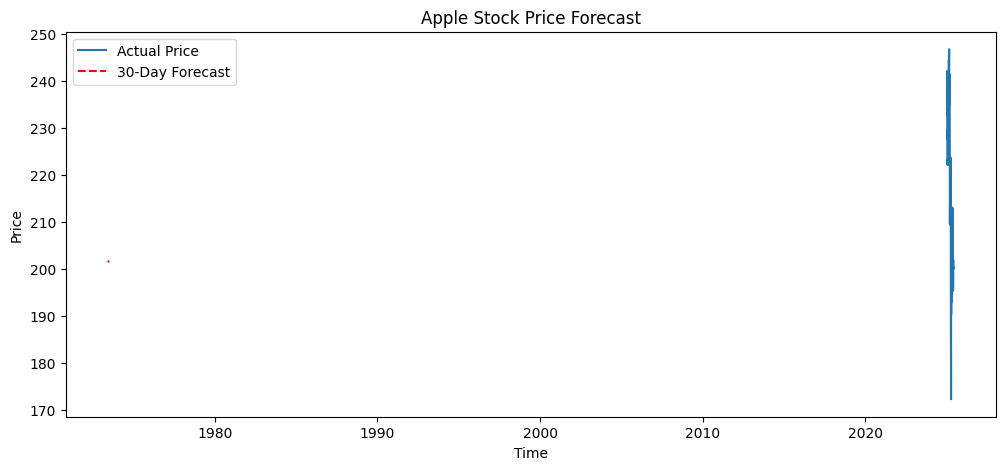

In [15]:
# Plot actual prices and forecast

plt.figure(figsize=(12,5))

# Last 100 actual prices
plt.plot(close_prices[-100:], label='Actual Price')

# Forecasted prices
plt.plot(forecast, label='30-Day Forecast', color='red', linestyle='--')

# Titles and labels
plt.title('Apple Stock Price Forecast')
plt.xlabel('Time')
plt.ylabel('Price')

# Legend
plt.legend()

# Show chart
plt.show()

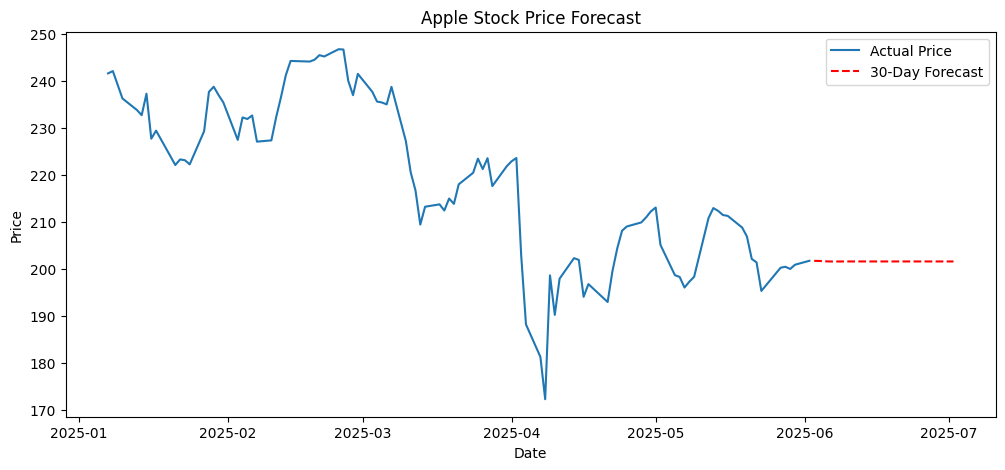

In [16]:
# Create future dates for forecast
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='D'
)[1:]

# Convert forecast into series with dates
forecast_series = pd.Series(forecast.values, index=future_dates)

# Plot actual prices
plt.figure(figsize=(12,5))

plt.plot(close_prices[-100:], label='Actual Price')

# Plot forecast with correct dates
plt.plot(forecast_series, label='30-Day Forecast',
         color='red', linestyle='--')

# Labels and title
plt.title('Apple Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price')

# Legend
plt.legend()

# Show chart
plt.show()

In [17]:
df.to_csv('cleaned_apple_stock.csv')